In [55]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pylatexenc.latexencode import unicode_to_latex as text2latex


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"

df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_17.08.csv")
# print(sorted(df.columns))
df = df.iloc[2:]
df = df.query("DistributionChannel=='anonymous'")

data_pts = []
for _, row in df.iterrows():
    # non_loop_merge_vars
    base_pt = {
        "pid": row['ResponseId'],
        "progress": row['Progress'],
        "duration": float(row['Duration (in seconds)'])/60,
        "finished": row['Finished'],
        "llm_usage": row['dv_llm_usage'],
        "usage_convention": row['dv_usage_convention'],
        "usage_moral": row['dv_usage_moral'],
        "usage_personal": row['dv_usage_personal'],
        "llm_usage_binary": did_use(row['dv_llm_usage']),
        "usage_convention_binary": did_use(row['dv_usage_convention']),
        "usage_moral_binary": did_use(row['dv_usage_moral']),
        "usage_personal_binary": did_use(row['dv_usage_personal']),
    }

    # loop and merge columns:
    for i in range(1, 60):
        pre = float(row.get(f'{i}_lm_pre_11'))
        post =float( row.get(f'{i}_lm_post_11'))
        qual = row.get(f'{i}_lm_qual')
        if pd.notnull(pre) and pd.notnull(post):
            data_pt = base_pt.copy()
            data_pt['idx'] = i
            data_pt['pre'] = pre
            data_pt['post'] = post
            data_pt['qual'] = qual
            data_pts.append(data_pt)

df = pd.DataFrame(data_pts)
meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
df = df.merge(meta_df, on='idx', how='left')
df['sum_usage'] = df[['usage_convention_binary', 'usage_moral_binary', 'usage_personal_binary']].sum(axis=1)

df['pre_distance'] = np.abs(df['pre'] - df['rating'])
df['post_distance'] = np.abs(df['post'] - df['rating'])
df['change_distance'] = df['pre_distance'] - df['post_distance']
df['domain'] = df['domain'].map(short_domain)

 # Descriptives of change

/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/1804359511.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


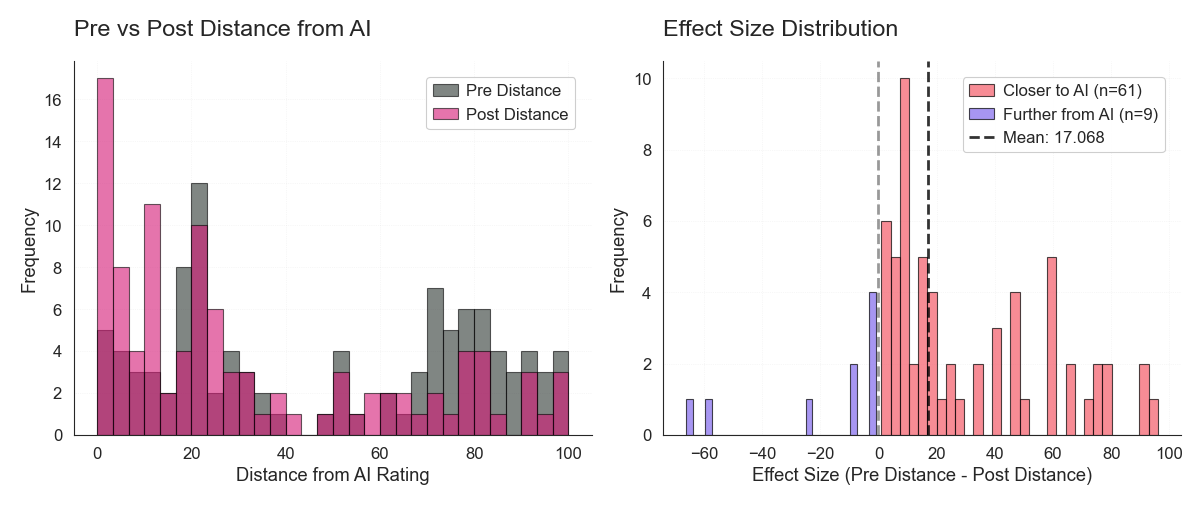


    The mean effect (pre-distance minus post-distance) was 17.07 (SD = 28.88), with a Cohen's dz of 0.59 (95% CI [0.42, 0.76]). In 59% of cases, participants moved closer to the AI rating, while in 9% of cases they moved further away, and in 32% of cases there was no change. A Wilcoxon signed-rank test indicates that this change is statistically significant (W = 206.0, p = 1.3e-09).


In [101]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pre_distance and post_distance as overlaid histograms
#################################################################
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=0.6, label='Pre Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=0.6, label='Post Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribution of effect sizes
#################################################################
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=0.7, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[4], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=0.7, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[3], edgecolor='black')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.8, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Statistics
######################################
######################################
def bootstrap_dz(data, n_bootstraps=10000):
    boot_dz = []
    n = len(data)
    for _ in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])


def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue
    }
    stats_str = f"""
    The mean effect (pre-distance minus post-distance) was {mean_diff:.2f} (SD = {sd_diff:.2f}), with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]). In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, while in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. A Wilcoxon signed-rank test indicates that this change is statistically significant (W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e})."""
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



## By factors

/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:15: FutureWarning: 

Passing `palette` without assi

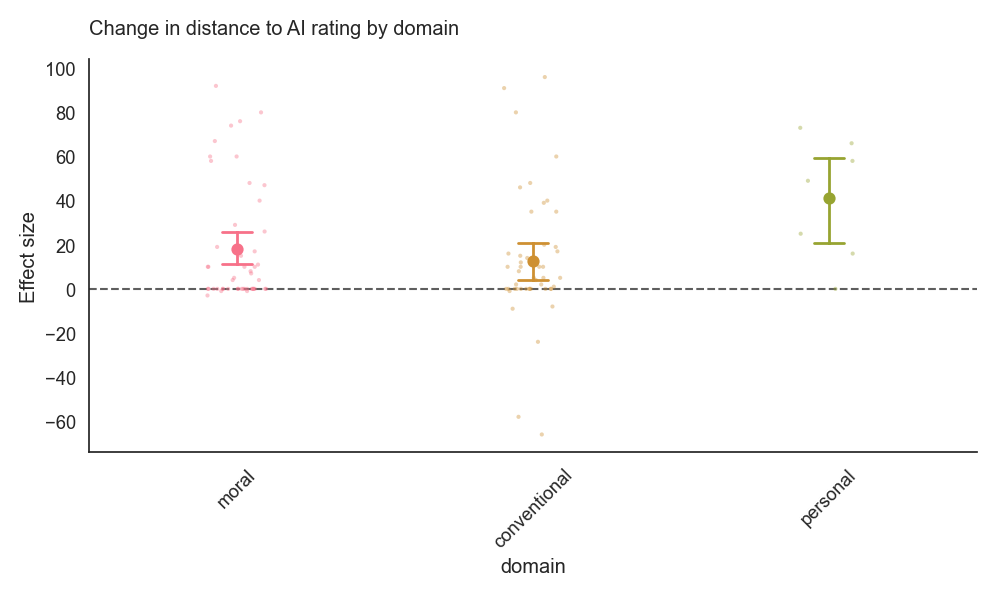


Descriptive statistics for domain:
              count    mean     std
domain                             
conventional     47  12.532  29.849
moral            49  18.000  26.810
personal          7  41.000  27.580


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:15: FutureWarning: 

Passing `palette` without assi

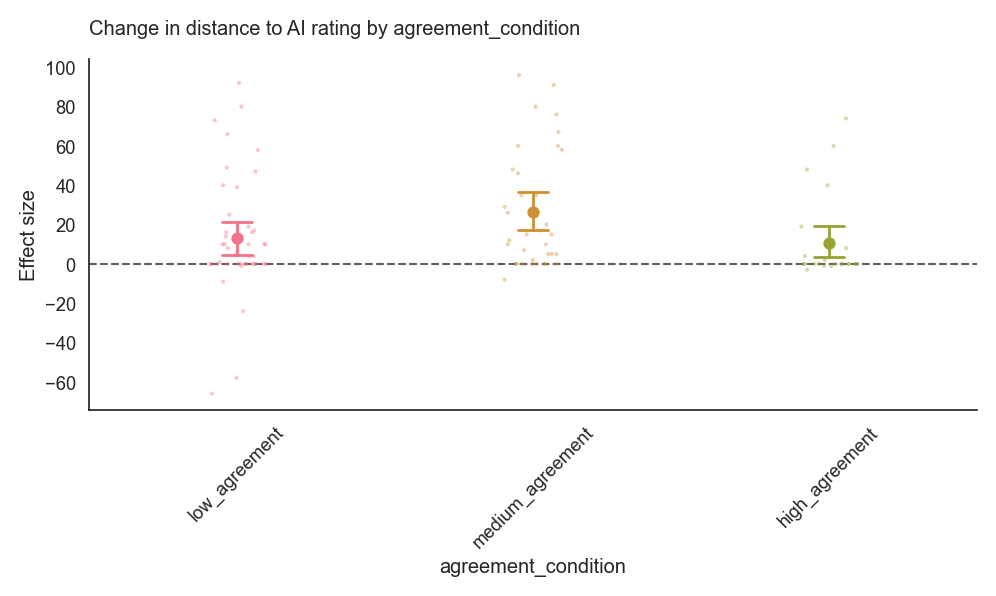

/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,



Descriptive statistics for agreement_condition:
                     count    mean     std
agreement_condition                       
high_agreement          24  10.833  21.588
low_agreement           44  13.091  30.196
medium_agreement        35  26.343  29.951


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:15: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_23573/2090027916.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


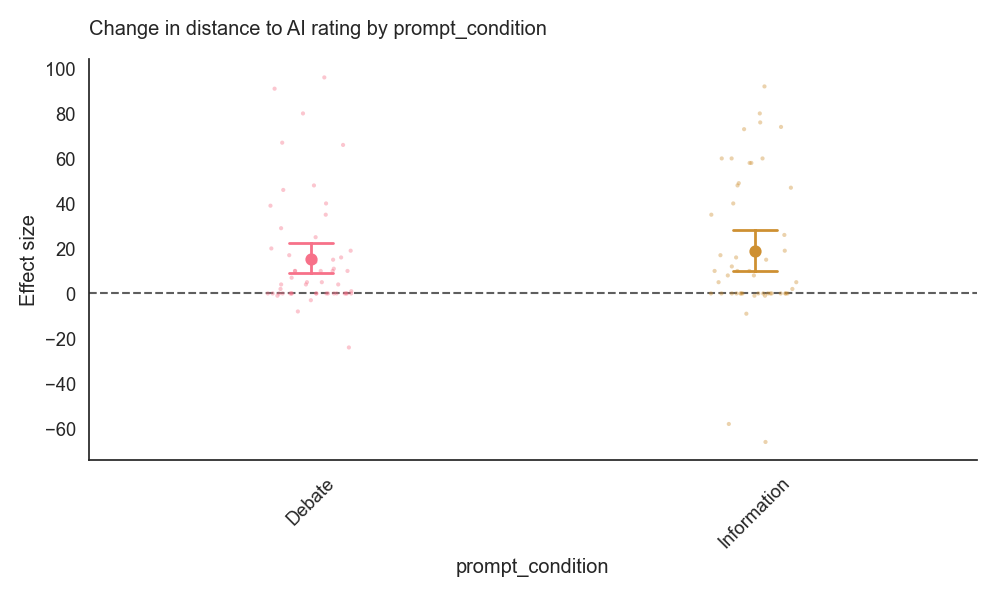


Descriptive statistics for prompt_condition:
                  count    mean     std
prompt_condition                       
Debate               53  15.472  25.358
Information          50  18.760  32.373


/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:85: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sum_res = pd.read_html(self.model.summary().tables[1].as_html(), header=0, index_col=0)[0].reset_index()
/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(y='var', x='coef', data=sum_res, capsize=0.1,


<module 'matplotlib.pyplot' from '/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/.venv12/lib/python3.12/site-packages/matplotlib/pyplot.py'>

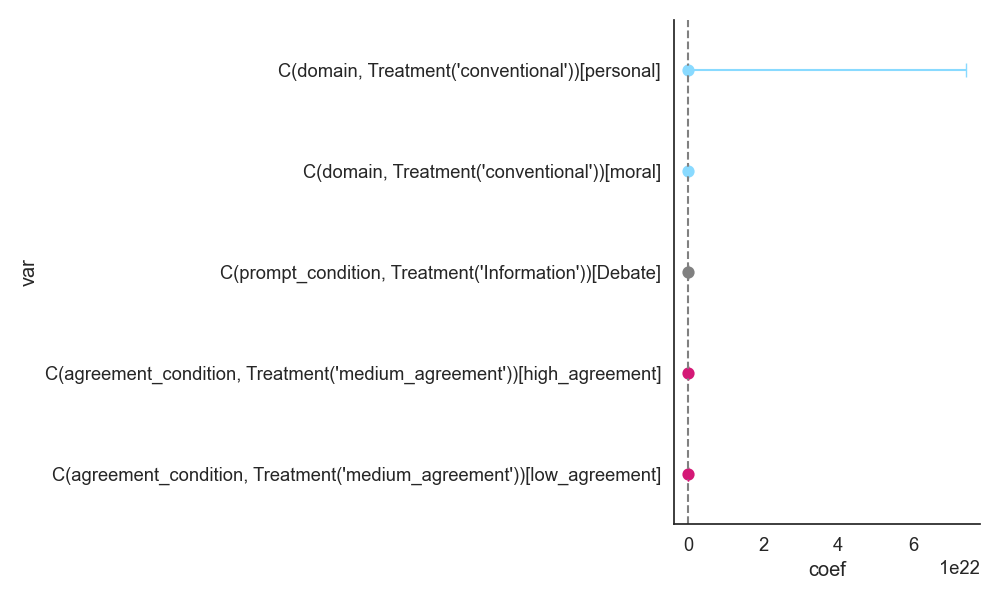

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import pandas as pd


# Create plots for each factor
for factor in ['domain', 'agreement_condition', 'prompt_condition']:
    plt.figure(figsize=(10, 6))
    mypal = make_aesthetic(font_scale=1.2)
    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.title(f"Change in distance to AI rating by {factor}")
    plt.ylabel("Effect size")
    plt.tight_layout()
    plt.show()

    # Print basic stats
    print(f"\nDescriptive statistics for {factor}:")
    print(df.groupby(factor)['change_distance'].agg(['count', 'mean', 'std']).round(3))



from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula


formula = "change_distance ~ C(domain, Treatment('conventional')) + C(agreement_condition, Treatment('medium_agreement')) + C(prompt_condition, Treatment('Information'))"
model = smf.ols(formula, data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['pid']}
)
handler = StatsmodelsHandler(model)
handler.plot(model)


In [116]:
df['prompt_condition']

0           Debate
1      Information
2           Debate
3      Information
4           Debate
          ...     
98     Information
99          Debate
100         Debate
101         Debate
102    Information
Name: prompt_condition, Length: 103, dtype: object

In [106]:
df.columns

Index(['pid', 'progress', 'duration', 'finished', 'llm_usage',
       'usage_convention', 'usage_moral', 'usage_personal', 'llm_usage_binary',
       'usage_convention_binary', 'usage_moral_binary',
       'usage_personal_binary', 'idx', 'pre', 'post', 'qual', 'rot',
       'experiment_condition', 'rating', 'prompt', 'low_or_high',
       'llm_response_rot', 'prompt_condition', 'domain', 'agreement_condition',
       'sum_usage', 'pre_distance', 'post_distance', 'change_distance',
       'ai_direction'],
      dtype='object')

In [120]:
help(handler.plot)

Help on method plot in module src.statsmodels_handler:

plot(exp=False, figsize=(10, 6), color_dict=None, drop_intercept=True, clean_var_name=None) method of src.statsmodels_handler.StatsmodelsHandler instance
    Plot model coefficients with confidence intervals and optional color coding.

    Args:
        exp (bool): If True, exponentiate coefficients (e.g., for odds ratios).
        figsize (tuple): Size of the plot figure.
        color_dict (dict): Colors for significance: {'ns', 'neg', 'pos'}.
        drop_intercept (bool): If True, omit the intercept term from the plot.
        clean_var_name (function): Optional function to clean variable names for plotting.

    Returns:
        matplotlib.pyplot object: The resulting plot.



/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:85: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sum_res = pd.read_html(self.model.summary().tables[1].as_html(), header=0, index_col=0)[0].reset_index()
/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/src/statsmodels_handler.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(y='var', x='coef', data=sum_res, capsize=0.1,


<module 'matplotlib.pyplot' from '/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/.venv12/lib/python3.12/site-packages/matplotlib/pyplot.py'>

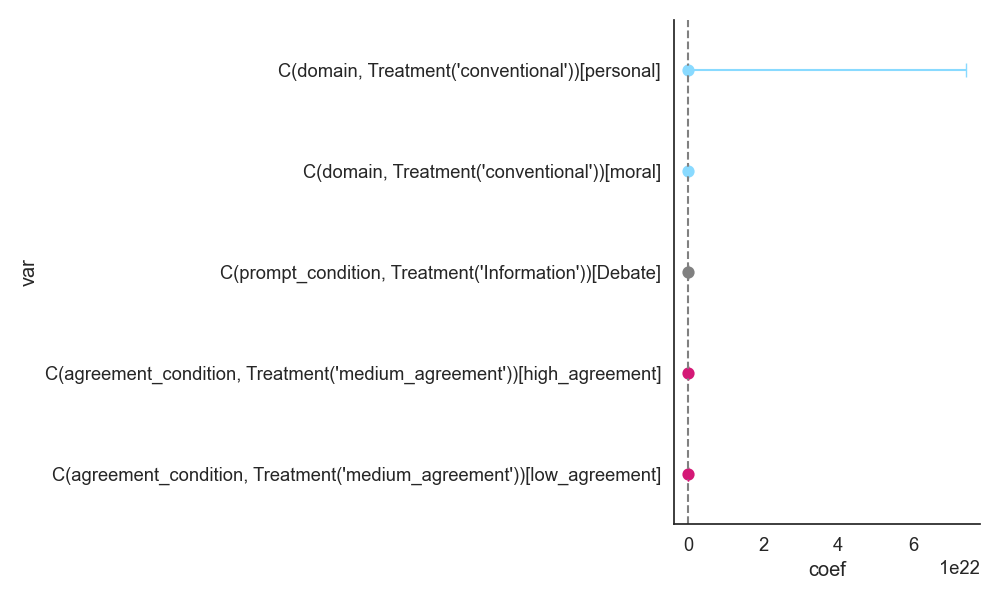

In [129]:
handler.plot(model.summary(), clean_var_name=clean_var_name_from_formula)


In [123]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        change_distance   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     5.183
Date:                Sat, 23 Aug 2025   Prob (F-statistic):             0.0204
Time:                        18:22:19   Log-Likelihood:                -483.47
No. Observations:                 103   AIC:                             978.9
Df Residuals:                      97   BIC:                             994.8
Df Model:                           5                                         
Covariance Type:              cluster                                         
===========================================================================================================================================
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  26.3098      8.025      3.279      0.001      10.582      42.038
C(domain, Treatment('conventional'))[T.moral]                               7.3355      3.464      2.118      0.034       0.546      14.125
C(domain, Treatment('conventional'))[T.personal]                           36.5357      8.227      4.441      0.000      20.411      52.661
C(agreement_condition, Treatment('medium_agreement'))[T.high_agreement]   -18.2053      6.027     -3.020      0.003     -30.019      -6.392
C(agreement_condition, Treatment('medium_agreement'))[T.low_agreement]    -19.7245      7.925     -2.489      0.013     -35.258      -4.191
C(prompt_condition, Treatment('Information'))[T.Debate]                    -4.9489      6.290     -0.787      0.431     -17.277       7.379
==============================================================================
Omnibus:                       13.398   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.624
Skew:                           0.732   Prob(JB):                     0.000405
Kurtosis:                       4.224   Cond. No.                         6.00
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""